# Example for consensus
This notebook demonstrates how the multiplicative weights algorithm can enhance the robustness of a consensus algorithm against Byzantine attacks.

## 1. Set some global parameters:

In [1256]:
from multiprocessing import Pool
from numpy import float64
from numpy.typing import NDArray

if __name__ == "__main__":
    N_STATE = 3
    N_ITER = 500
    ALPHA = 0.3

    NORMAL_LB = -100.0  # Lower bound of normal nodes' initial state values
    NORMAL_UB = 100.0  # Upper bound of normal nodes' initial state values

## 2. Define the graph topology and characterize the behavior of Byzantine nodes.
### (1) Define the graph

We consider a network consisting of two categories of nodes with corresponding edges:

```python
NORMAL_NODES = [...]
NORMAL_EDGES = [...]

BYZANTINE_NODES = [...]
BYZANTINE_EDGES = [...]
```

The overall network is formed by the union of the normal and Byzantine nodes and edges:

$$
\mathcal{I} = \mathcal{I}_\text{normal} \cup \mathcal{I}_\text{Byz}, \quad \mathcal{E} = \mathcal{E}_\text{normal} \cup \mathcal{E}_\text{Byz}.
$$

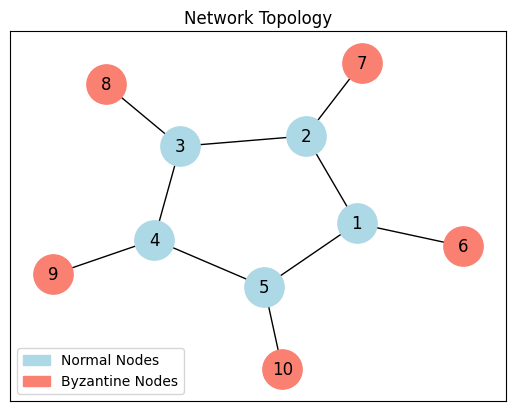

In [1257]:
def graph_server(nodes: list[str], edges: list[tuple[str, str]]) -> None:
    from logging import basicConfig, INFO

    basicConfig(level=INFO)

    from topolink import Graph

    graph = Graph(nodes, edges)

    graph.deploy()


if __name__ == "__main__":
    NORMAL_NODES = ["1", "2", "3", "4", "5"]
    NORMAL_EDGES = [("1", "2"), ("2", "3"), ("3", "4"), ("4", "5"), ("5", "1")]
    BYZANTINE_NODES = ["6", "7", "8", "9", "10"]
    BYZANTINE_EDGES = [("1", "6"), ("2", "7"), ("3", "8"), ("4", "9"), ("5", "10")]

    # A typical network topology that can be used to test overly conservative designs
    # NORMAL_NODES = ["1", "2", "3", "4", "5", "6", "7"]
    # NORMAL_EDGES = [
    #     ("1", "2"),
    #     ("2", "3"),
    #     ("3", "4"),
    #     ("4", "5"),
    #     ("5", "1"),
    #     ("1", "6"),
    #     ("5", "6"),
    #     ("3", "7"),
    #     ("4", "7"),
    # ]
    # BYZANTINE_NODES = []
    # BYZANTINE_EDGES = []

    NODES = NORMAL_NODES + BYZANTINE_NODES
    EDGES = NORMAL_EDGES + BYZANTINE_EDGES

    N_NORMAL = len(NORMAL_NODES)
    N_BYZANTINE = len(BYZANTINE_NODES)
    N_NODES = N_NORMAL + N_BYZANTINE

    import matplotlib.pyplot as plt
    import networkx as nx

    fig, ax = plt.subplots()
    ax.set_title("Network Topology")

    G = nx.Graph()
    G.add_nodes_from(NODES)
    G.add_edges_from(EDGES)

    pos = nx.spring_layout(G, seed=11, k=0.8)

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=NORMAL_NODES,
        node_color="lightblue",
        node_size=800,
        ax=ax,
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=BYZANTINE_NODES,
        node_color="salmon",
        node_size=800,
        ax=ax,
    )

    nx.draw_networkx_edges(G, pos, ax=ax)
    nx.draw_networkx_labels(G, pos, ax=ax)

    import matplotlib.patches as mpatches

    blue_patch = mpatches.Patch(color="lightblue", label="Normal Nodes")
    red_patch = mpatches.Patch(color="salmon", label="Byzantine Nodes")

    ax.legend(handles=[blue_patch, red_patch], loc="lower left")

### (2) Define the behavior of Byzantine nodes

A Byzantine node ignores the states of its neighbors.
Let the state of node $i$ at iteration $t$ be denoted as $x_i^{(t)}$.
Then the update rule for a Byzantine node can be described as:

1. **Keep state constant:**
$$
x_i^{(t + 1)} = x_i^{(t)}
$$

2. **Update state randomly:**
$$
x_i^{(t)} \sim \mathcal{U}(a, b)
$$
where $\mathcal{U}(a, b)$ denotes a uniform random variable in the range $[a, b]$, which represents the possible values that the Byzantine node can take.

3. **Add perturbation:**
$$
x_i^{(t + 1)} = x_i^{(t)} - \alpha \sum_{j \in \mathcal{N}_i}(x_i^{(t)} - x_j^{(t)}) + \eta_i^{(t)}
$$
where $\eta_i^{(t)}$ is an interference term (noise) that can be modeled as either deterministic or stochastic, e.g.
$$
\eta_i^{(t)} \sim \mathcal{U}(a, b).
$$
This form represents a Byzantine node that actively injects perturbations into its state to disrupt the consensus process.

In [1258]:
def byzantine_node(
    name: str,
    n_state: int,
    alpha: float,
    n_iter: int,
    type: str,
    lower_bound: float,
    upper_bound: float,
) -> NDArray[float64]:
    from numpy import zeros
    from numpy.random import seed, uniform
    from topolink import NodeHandle

    nh = NodeHandle(name)

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        laplacian = nh.laplacian(states[k])

        if type == "constant":
            states[k + 1] = states[k]
        elif type == "random":
            states[k + 1] = uniform(lower_bound, upper_bound, n_state)
        elif type == "disturbance":
            disturbance = uniform(-0.5, 0.5, n_state)
            states[k + 1] = states[k] - laplacian * alpha + disturbance

    return states


if __name__ == "__main__":
    BYZ_TYPE = "constant"  # Byzantine behavior: "constant", "random", "disturbance"
    BYZ_LB = -100.0
    BYZ_UB = 100.0

## 3. Execute a standard consensus algorithm

In our system, we use the consensus iteration to update the states of nodes. Let the global state vector of all nodes at iteration $k$ be denoted as $X^k \in \mathbb{R}^{nd}$, where $n$ is the number of nodes and $d$ is the dimension of each node's state. The consensus iteration is given by:

$$
X^{(t + 1)} = X^{(t)} - \alpha (L \otimes I_d) X^{(t)},
$$

where:  

- $L \in \mathbb{R}^{n \times n}$ is the **graph Laplacian matrix**, defined as $L = D - A$, with $A$ being the adjacency matrix of the network and $D$ the degree matrix.  
- $I_d \in \mathbb{R}^{d \times d}$ is the **identity matrix**, allowing the Laplacian to act independently on each dimension of the state.  
- $\otimes$ denotes the **Kronecker product**, which expands the Laplacian to operate on the multi-dimensional state vector.  
- $\alpha > 0$ is the **step size** or **learning rate**, controlling how much each node adjusts its state in each iteration.

### (1) Run the algorithm

In [1259]:
def baseline_node(
    name: str,
    n_state: int,
    alpha: float,
    n_iter: int,
    lower_bound: float,
    upper_bound: float,
) -> NDArray[float64]:
    from numpy import zeros
    from numpy.random import uniform, seed
    from topolink import NodeHandle

    nh = NodeHandle(name)

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        states[k + 1] = states[k] - nh.laplacian(states[k]) * alpha

    return states


if __name__ == "__main__":
    with Pool(N_NODES + 1) as pool:
        server = pool.apply_async(graph_server, args=(NODES, EDGES))
        baseline_nodes = {
            i: pool.apply_async(
                baseline_node, args=(i, N_STATE, ALPHA, N_ITER, NORMAL_LB, NORMAL_UB)
            )
            for i in NORMAL_NODES
        }
        byzantine_nodes = {
            i: pool.apply_async(
                byzantine_node,
                args=(i, N_STATE, ALPHA, N_ITER, BYZ_TYPE, BYZ_LB, BYZ_UB),
            )
            for i in BYZANTINE_NODES
        }
        baseline_states = {i: node.get() for i, node in baseline_nodes.items()}
        byzantine_states = {i: node.get() for i, node in byzantine_nodes.items()}
        server.get()

INFO:topolink.graph:Graph 'default' running on: 172.26.120.171:40193
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '2' joined graph 'default' from 172.26.120.171:41697.
INFO:topolink.graph:Node '7' joined graph 'default' from 172.26.120.171:43997.
INFO:topolink.graph:Node '9' joined graph 'default' from 172.26.120.171:37419.
INFO:topolink.graph:Node '5' joined graph 'default' from 172.26.120.171:44167.
INFO:topolink.graph:Node '1' joined graph 'default' from 172.26.120.171:45823.
INFO:topolink.graph:Node '3' joined graph 'default' from 172.26.120.171:40179.
INFO:topolink.graph:Node '6' joined graph 'default' from 172.26.120.171:42025.
INFO:topolink.graph:Node '10' joined graph 'default' from 172.26.120.171:46457.
INFO:topolink.graph:Node '8' joined graph 'default' from 172.26.120.171:33975.
INFO:topolink.graph:Node '4' joined graph 'default' from 172.26.120.171:40549.
INFO:topolink.graph:Graph 'default' registration complete.
INFO:topolin

### (2) Visualize the Results

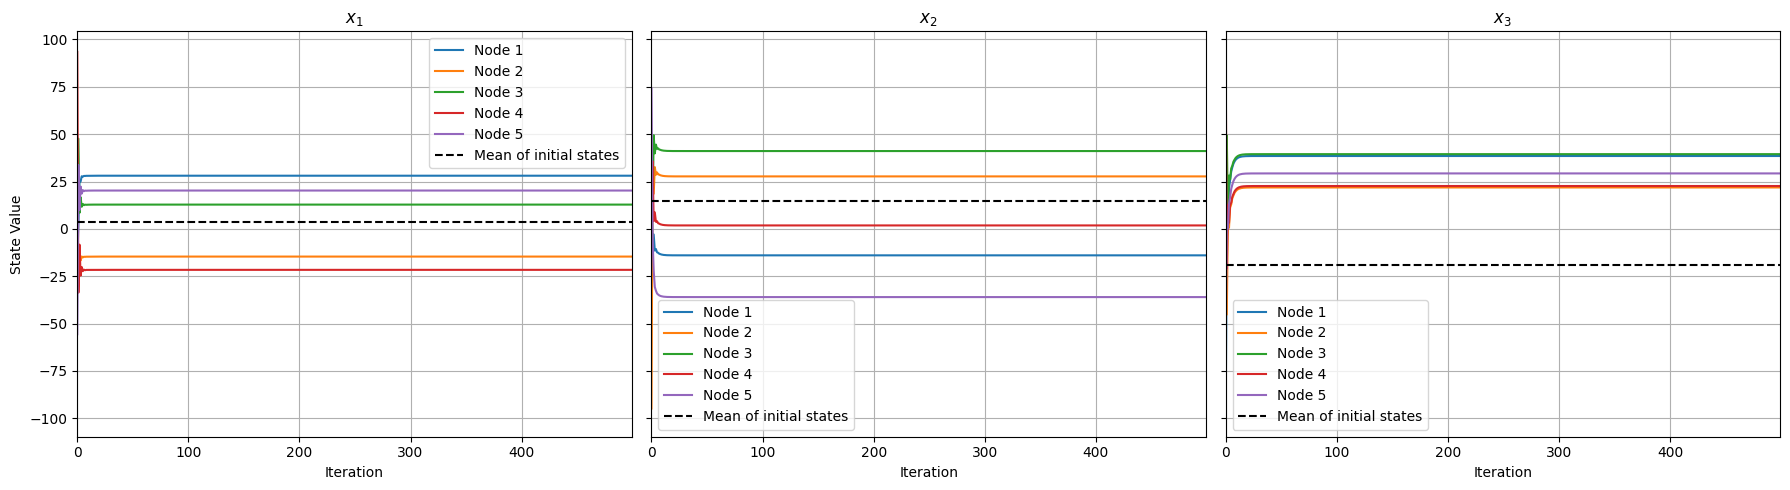

In [1260]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from matplotlib.axes import Axes
    from typing import Sequence

    ax1: Sequence[Axes]
    fig1, ax1 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i in NORMAL_NODES:
        states = baseline_states[i]
        for j in range(N_STATE):
            ax1[j].plot(states[:, j], label=f"Node {i}")

    from numpy import sum as np_sum

    initial_states = [baseline_states[i][0, :] for i in NORMAL_NODES]
    mean_states: NDArray[float64] = np_sum(initial_states, axis=0) / N_NORMAL

    for j in range(N_STATE):
        ax1[j].axhline(
            mean_states[j],
            color="k",
            linestyle="--",
            label="Mean of initial states",
        )

    for j in range(N_STATE):
        ax1[j].set_xlabel("Iteration")
        ax1[j].set_xlim(0, N_ITER - 1)
        ax1[j].legend()
        ax1[j].set_title(f"$x_{j + 1}$")
        ax1[j].grid()

    ax1[0].set_ylabel("State Value")

    fig1.tight_layout()

## 4. Exponential reputation-based consensus algorithm
---
### Multiplicative weights update

For a system with $n$ experts, each expert $i$ is assigned a weight $\omega_i^{(t)}$ at time step $t$.
At this step, expert $i$ incurs a loss $l_i^{(t)}$, and its weight is subsequently updated according to one of the following rules.

#### 1. Linear update
$$
\omega_i^{(t + 1)} = \omega_i^{(t)} (1 - \eta l_i^{(t)})
$$
where $\eta$ is the learning rate parameter.

This linear update is simple to compute but can lead to negative weights when $\eta l_i^{(t)} > 1$, and it is less convenient for theoretical analysis.

#### 2. Exponential update (Hedge)
In practice, the exponential update is typically preferred:
$$
\boxed{\omega_i^{(t + 1)} = \omega_i^{(t)} e^{-\eta l_i^{(t)}}}
$$
where $\eta > 0$ is the learning rate.

For small values of $\eta$, note that:
$$
e^{-\eta l_i^{(t)}} \approx 1 - \epsilon l_i^{(t)},
$$
so the linear rule can be viewed as a first-order approximation of the exponential update.

It is often more convenient to express this update in terms of the **cumulative loss**:
$$
L_i^{(t)} = \sum_{\tau = 0}^{t} l_i^{(\tau)}.
$$
Substituting this definition into the recursive rule yields the following closed-form expression:
$$
\boxed{\omega_i^{(t)} = \exp(-\eta L_i^{(t)})}.
$$
This formulation is commonly used in practice, as it avoids repeated multiplications and makes explicit how each expert’s weight decays exponentially with its cumulative loss.

Finally, to obtain a valid probability distribution over experts, the normalized weights are defined as:
$$
p_i^{(t)} = \frac{\omega_i^{(t)}}{\sum_j \omega_j^{(t)}}.
$$
Here, $p_i^{(t)}$ represents the normalized importance (or probability) assigned to expert $i$ at round $t$.


> **Note**
> The following notation is independent of the above; the above was written according to the original paper.

---
### Loss function

#### 1. Inconsistency loss
For each node $i$ and each neighbor $j \in \mathcal{N}_i$, we define the **loss** as

$$
l_{ij}^{(t)} = \sum_{v \in \mathcal{N}_i} \frac{\| x_j^{(t)} - x_v^{(t)} \|}{d_i},
$$

where $x_j^{(t)}$ denotes the state received from neighbor $j$ at iteration $t$, $\mathcal{N}_i$ is the set of neighbors of node $i$, and $d_i = |\mathcal{N}_i|$ denotes its degree.
This definition quantifies the local inconsistency between neighbor $j$ and the remaining neighbors of node $i$ at iteration $t$.
Assuming that honest neighbors outnumber malicious ones (e.g., at least $3f+1$ nodes in total), the majority of consistent neighbors will yield smaller losses, while Byzantine neighbors tend to have larger ones.

However, this metric has two limitations.  
1) First, when Byzantine nodes adopt **extreme strategies**—for example, broadcasting excessively large or small values—this loss **cannot be normalized**. Once normalized, the losses of honest and Byzantine neighbors may become indistinguishable. Without normalization, due to the nature of the exponential function, even if the Byzantine nodes’ loss is only about twice that of the honest nodes, when the loss is large, the difference can still be significant.
2) Second, even when all honest neighbors have already reached consensus, the loss remains nonzero due to residual pairwise differences, which may lead to unnecessary penalization.

#### 2. Distance-from-median loss
Alternatively, we define a **median-based loss**, which quantifies the deviation of each neighbor's state from the element-wise median of all neighbors:

$$
l_{ij}^{(t)} = \| x_j^{(t)} - x_{\text{med}}^{(t)} \|_1,
$$

where 
$$
x_{\text{med}}^{(t)} = \operatorname{median}\big(\{ x_v^{(t)} : v \in \mathcal{N}_i \}\big)
$$
denotes the element-wise median of node $i$’s neighbors at iteration $t$.

---
### Discounted memory

In standard implementations, the exponential weighting rule is typically based on the **cumulative loss**:

$$
\omega_{ij}^{(t)} = \exp(-\eta\, L_{ij}^{(t)}),
$$

where $L_{ij}^{(t)}$ sums the losses over all previous iterations.

However, using cumulative loss has two limitations in our setting:
1. **Past information may be misleading.** Due to the highly dynamic nature of Byzantine attacks, a malicious node could behave honestly for several rounds before attacking. Retaining long-term memory would cause such nodes to maintain high trust, compromising system reliability.
2. **Losses among honest nodes may differ even after consensus.** When honest neighbors converge, their cumulative losses are generally not equal. Standard multiplicative weight update (MWU) algorithms would then favor one "best" node over others, resulting in unequal weights among honest nodes. This contradicts our goal of **treating all honest nodes equally**.

To address these issues while still preserving short-term memory, we adopt a **decayed cumulative loss** with a **forgetting factor** $\lambda \in (0,1]$:

$$
\tilde{L}_{ij}^{(t)} = \lambda\, \tilde{L}_{ij}^{(t-1)} + l_{ij}^{(t)}.
$$

Accordingly, the weight update becomes

$$
\boxed{\omega_{ij}^{(t)} = \exp(-\eta\, \tilde{L}_{ij}^{(t)})}.
$$

This formulation ensures that recent observations have a stronger influence, mitigating the impact of outdated information while retaining a smoothed history. By adjusting \( \lambda \), the system can balance responsiveness to sudden changes against stability in the presence of benign fluctuations.

When $\lambda = 0$, the formulation degenerates to the instantaneous-loss case.

---
### Local state update

At each iteration, node $i$ first obtains an **estimate** $\hat{x}_i^{(t)}$ of its consensus value based on the states of its neighbors.
The estimate is computed as a weighted average of the neighbors’ states:
$$
\hat{x}_{i}^{(t)} = \sum_{j \in \mathcal{N}_i} p_j^{(t)} x_j^{(t)}.
$$

Subsequently, node $i$ **updates its local state** according to
$$
x_i^{(t + 1)} = (1 - \alpha) x_i^{(t)} + \alpha \hat{x}_i^{(t)},
$$
where $\alpha \in [0, 1]$ is a weighting factor that balances the influence of the new estimate and the previous state.

---

### (1) Run the algorithm

In [1261]:
def mw_node(
    name: str,
    n_state: int,
    alpha: float,
    n_iter: int,
    lower_bound: float,
    upper_bound: float,
) -> tuple[NDArray[float64], dict[str, NDArray[float64]]]:
    from numpy import zeros
    from numpy.random import uniform, seed
    from topolink import NodeHandle

    nh = NodeHandle(name)

    from xrepc import XRepC

    xrepc = XRepC(nh.neighbor_names, alpha=alpha, eta=0.1)

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    probs = {neighbor: zeros(n_iter - 1) for neighbor in nh.neighbor_names}

    for k in range(n_iter - 1):
        # Broadcast current state (make decision) and gather neighbors' states (observe results)
        nh.broadcast(states[k])
        state_js = nh.gather()

        # Compute new state
        states[k + 1] = xrepc.aggregate(states[k], state_js)

        # Record normalized weights history
        p = xrepc.probs
        for neighbor in nh.neighbor_names:
            probs[neighbor][k] = p[neighbor]

    return states, probs


if __name__ == "__main__":
    with Pool(N_NODES + 1) as pool:
        server = pool.apply_async(graph_server, args=(NODES, EDGES))
        mw_nodes = {
            i: pool.apply_async(
                mw_node, args=(i, N_STATE, ALPHA, N_ITER, NORMAL_LB, NORMAL_UB)
            )
            for i in NORMAL_NODES
        }
        byzantine_nodes = {
            i: pool.apply_async(
                byzantine_node,
                args=(i, N_STATE, ALPHA, N_ITER, BYZ_TYPE, BYZ_LB, BYZ_UB),
            )
            for i in BYZANTINE_NODES
        }
        xrepc_results = {i: node.get() for i, node in mw_nodes.items()}
        byzantine_states = {i: node.get() for i, node in byzantine_nodes.items()}
        server.get()

INFO:topolink.graph:Graph 'default' running on: 172.26.120.171:42917
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '6' joined graph 'default' from 172.26.120.171:45439.
INFO:topolink.graph:Node '10' joined graph 'default' from 172.26.120.171:42379.
INFO:topolink.graph:Node '3' joined graph 'default' from 172.26.120.171:41373.
INFO:topolink.graph:Node '8' joined graph 'default' from 172.26.120.171:41871.
INFO:topolink.graph:Node '5' joined graph 'default' from 172.26.120.171:36911.
INFO:topolink.graph:Node '4' joined graph 'default' from 172.26.120.171:42257.
INFO:topolink.graph:Node '2' joined graph 'default' from 172.26.120.171:41169.
INFO:topolink.graph:Node '9' joined graph 'default' from 172.26.120.171:45175.
INFO:topolink.graph:Node '1' joined graph 'default' from 172.26.120.171:42467.
INFO:topolink.graph:Node '7' joined graph 'default' from 172.26.120.171:42209.
INFO:topolink.graph:Graph 'default' registration complete.
INFO:topolin

### (2) Visualize the Results

#### 1. State evolution for each normal node

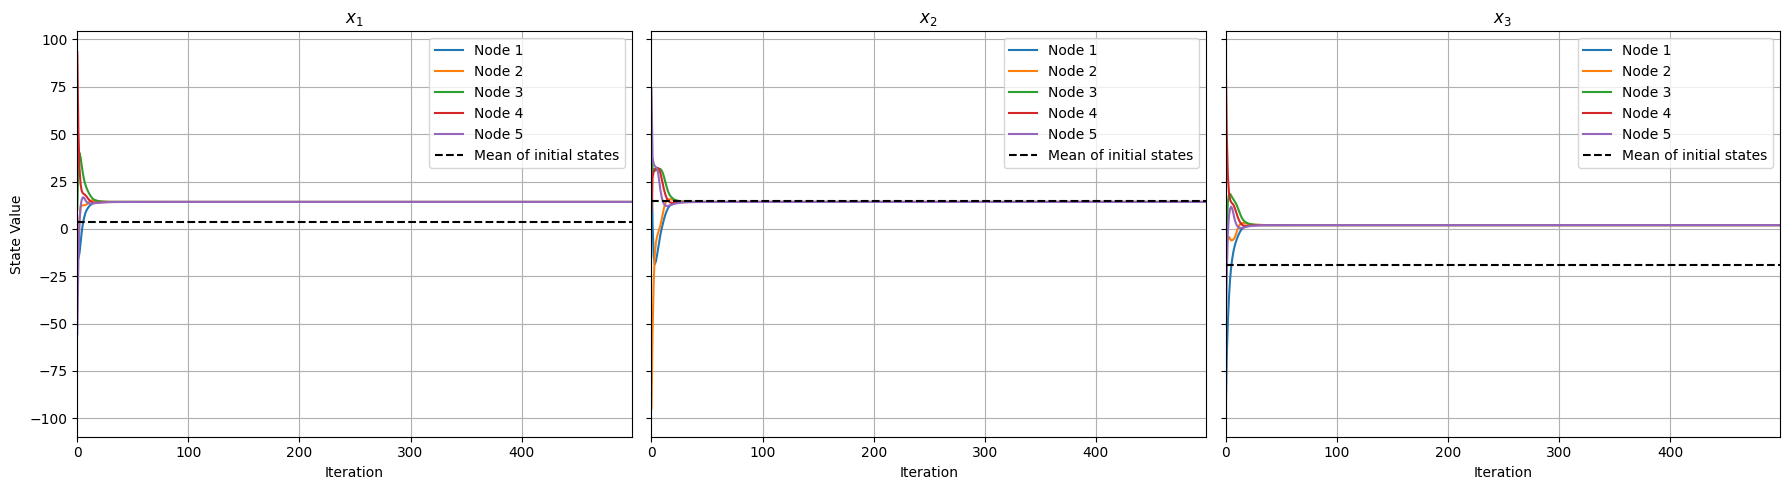

In [1262]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from matplotlib.axes import Axes
    from typing import Sequence

    ax2: Sequence[Axes]
    fig2, ax2 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    xrepc_states = {i: xrepc_results[i][0] for i in NORMAL_NODES}

    for i in NORMAL_NODES:
        states = xrepc_states[i]
        for j in range(N_STATE):
            ax2[j].plot(states[:, j], label=f"Node {i}")

    from numpy import sum as np_sum

    initial_states = [xrepc_states[i][0, :] for i in NORMAL_NODES]
    mean_states: NDArray[float64] = np_sum(initial_states, axis=0) / N_NORMAL

    for j in range(N_STATE):
        ax2[j].axhline(
            mean_states[j], color="k", linestyle="--", label="Mean of initial states"
        )

    for j in range(N_STATE):
        ax2[j].set_xlabel("Iteration")
        ax2[j].set_xlim(0, N_ITER - 1)
        ax2[j].legend()
        ax2[j].set_title(f"$x_{j + 1}$")
        ax2[j].grid()

    ax2[0].set_ylabel("State Value")

    fig2.tight_layout()

#### 2. Weight evolution for each node

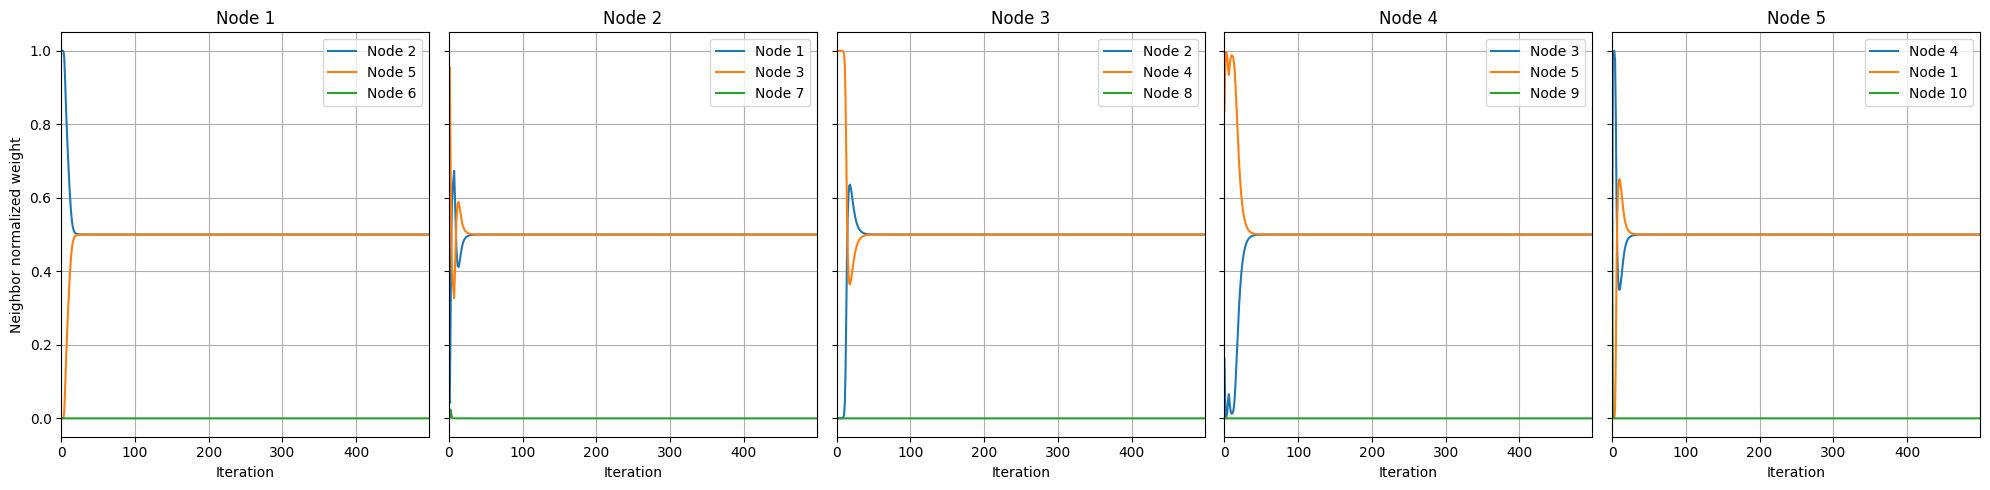

In [1263]:
if __name__ == "__main__":
    ax3: Sequence[Axes]
    fig3, ax3 = plt.subplots(1, N_NORMAL, figsize=(20, 5), sharey=True)

    xrepc_probs = {i: xrepc_results[i][1] for i in NORMAL_NODES}

    for i, ax in zip(NORMAL_NODES, ax3):
        probs_for_i = xrepc_probs[i]
        for j in probs_for_i:
            ax.plot(probs_for_i[j], label=f"Node {j}")
        ax.set_title(f"Node {i}")
        ax.set_xlabel("Iteration")
        ax.set_xlim(0, N_ITER - 1)
        ax.legend()
        ax.grid()

    ax3[0].set_ylabel("Neighbor normalized weight")

    fig3.tight_layout()

## 5. Reputation-based consensus

---

### (1) Run the algorithm

In [1264]:
def repc_node(
    name: str,
    n_state: int,
    alpha: float,
    n_iter: int,
    lower_bound: float,
    upper_bound: float,
) -> tuple[NDArray[float64], dict[str, NDArray[float64]]]:
    from topolink import NodeHandle

    nh = NodeHandle(name)

    from xrepc.baselines import RepC

    repc = RepC(nh.neighbor_names, alpha=alpha)

    from numpy import zeros
    from numpy.random import uniform, seed

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    probs = {neighbor: zeros(n_iter - 1) for neighbor in nh.neighbor_names}

    for k in range(n_iter - 1):
        # Update state
        nh.broadcast(states[k])
        state_js = nh.gather()

        # Compute new state
        states[k + 1] = repc.aggregate(states[k], state_js)

        # Record normalized weights history
        p = repc.probs
        for neighbor in nh.neighbor_names:
            probs[neighbor][k] = p[neighbor]

    return states, probs


if __name__ == "__main__":
    with Pool(N_NODES + 1) as pool:
        server = pool.apply_async(graph_server, args=(NODES, EDGES))
        repc_nodes = {
            i: pool.apply_async(
                repc_node, args=(i, N_STATE, ALPHA, N_ITER, NORMAL_LB, NORMAL_UB)
            )
            for i in NORMAL_NODES
        }
        byzantine_nodes = {
            i: pool.apply_async(
                byzantine_node,
                args=(i, N_STATE, ALPHA, N_ITER, BYZ_TYPE, BYZ_LB, BYZ_UB),
            )
            for i in BYZANTINE_NODES
        }
        repc_results = {i: node.get() for i, node in repc_nodes.items()}
        byzantine_states = {i: node.get() for i, node in byzantine_nodes.items()}
        server.get()

INFO:topolink.graph:Graph 'default' running on: 172.26.120.171:38901
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '7' joined graph 'default' from 172.26.120.171:43955.
INFO:topolink.graph:Node '5' joined graph 'default' from 172.26.120.171:45771.
INFO:topolink.graph:Node '3' joined graph 'default' from 172.26.120.171:44493.
INFO:topolink.graph:Node '8' joined graph 'default' from 172.26.120.171:44423.
INFO:topolink.graph:Node '2' joined graph 'default' from 172.26.120.171:40169.
INFO:topolink.graph:Node '1' joined graph 'default' from 172.26.120.171:45887.
INFO:topolink.graph:Node '9' joined graph 'default' from 172.26.120.171:39179.
INFO:topolink.graph:Node '10' joined graph 'default' from 172.26.120.171:40835.
INFO:topolink.graph:Node '6' joined graph 'default' from 172.26.120.171:42647.
INFO:topolink.graph:Node '4' joined graph 'default' from 172.26.120.171:41533.
INFO:topolink.graph:Graph 'default' registration complete.
INFO:topolin

### (2) Visualize the Results

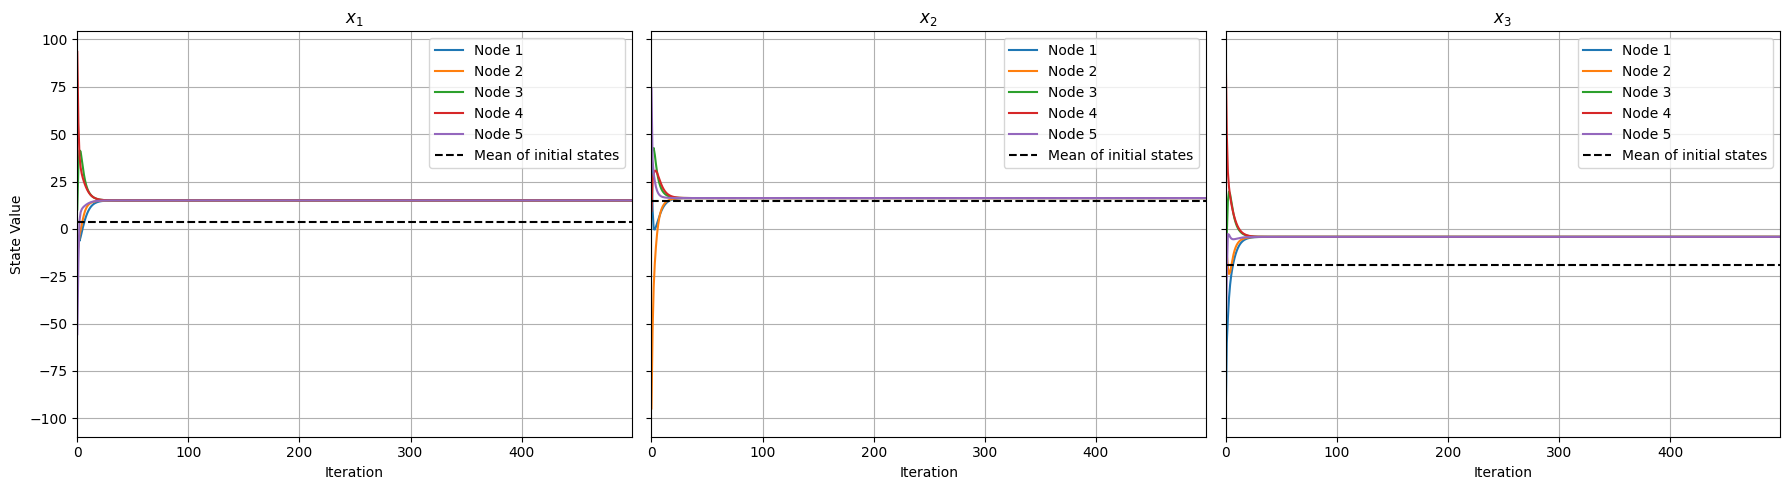

In [1265]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from matplotlib.axes import Axes
    from typing import Sequence

    ax4: Sequence[Axes]
    fig4, ax4 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    repc_states = {i: repc_results[i][0] for i in NORMAL_NODES}

    for i in NORMAL_NODES:
        states = repc_states[i]
        for j in range(N_STATE):
            ax4[j].plot(states[:, j], label=f"Node {i}")

    from numpy import sum as np_sum

    initial_states = [repc_states[i][0, :] for i in NORMAL_NODES]
    mean_states: NDArray[float64] = np_sum(initial_states, axis=0) / N_NORMAL

    for j in range(N_STATE):
        ax4[j].axhline(
            mean_states[j], color="k", linestyle="--", label="Mean of initial states"
        )

    for j in range(N_STATE):
        ax4[j].set_xlabel("Iteration")
        ax4[j].set_xlim(0, N_ITER - 1)
        ax4[j].legend()
        ax4[j].set_title(f"$x_{j + 1}$")
        ax4[j].grid()

    ax4[0].set_ylabel("State Value")

    fig4.tight_layout()

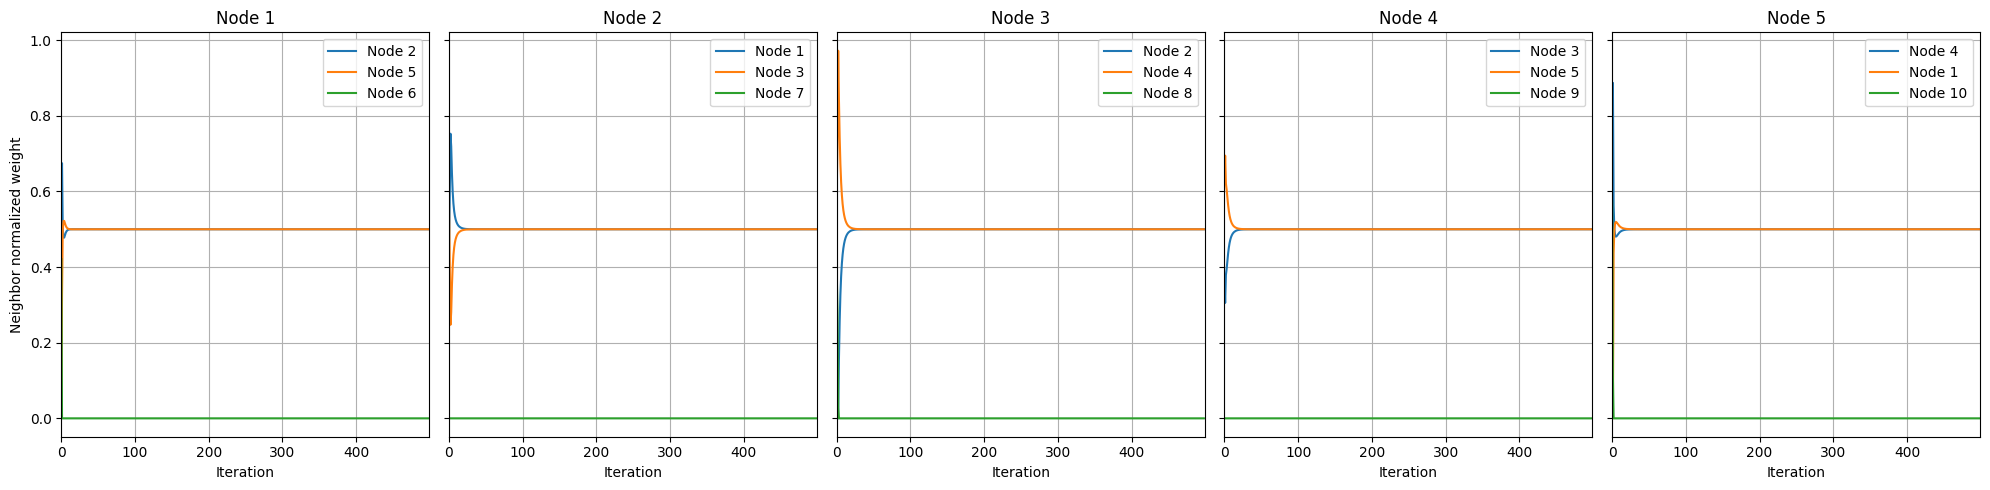

In [1266]:
if __name__ == "__main__":
    ax5: Sequence[Axes]
    fig5, ax5 = plt.subplots(1, N_NORMAL, figsize=(20, 5), sharey=True)

    repc_probs = {i: repc_results[i][1] for i in NORMAL_NODES}

    for i, ax in zip(NORMAL_NODES, ax5):
        probs_for_i = repc_probs[i]
        for j in probs_for_i:
            ax.plot(probs_for_i[j], label=f"Node {j}")
        ax.set_title(f"Node {i}")
        ax.set_xlabel("Iteration")
        ax.set_xlim(0, N_ITER - 1)
        ax.legend()
        ax.grid()

    ax5[0].set_ylabel("Neighbor normalized weight")

    fig5.tight_layout()

## 6. Byzantine attack type

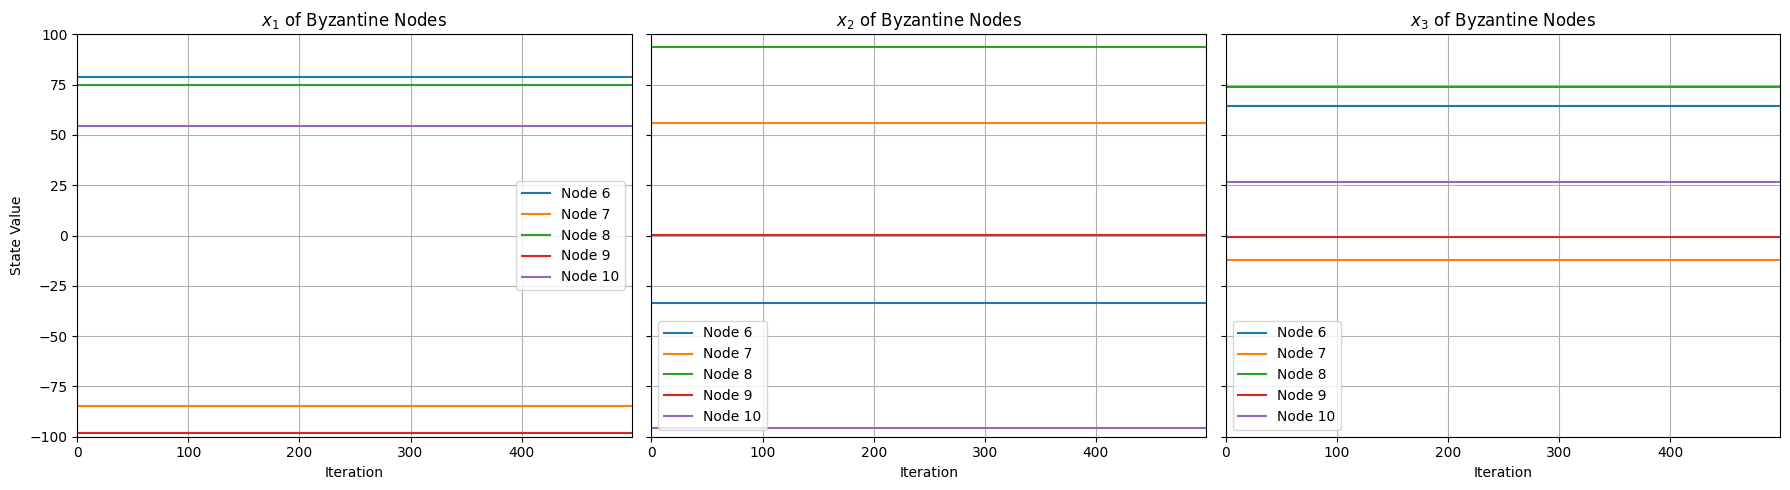

In [1267]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from matplotlib.axes import Axes
    from typing import Sequence

    ax5: Sequence[Axes]
    fig5, ax5 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i in BYZANTINE_NODES:
        states = byzantine_states[i]
        for j in range(N_STATE):
            ax5[j].plot(states[:, j], label=f"Node {i}")

    ax5[0].set_ylabel("State Value")
    ax5[0].set_ylim(BYZ_LB, BYZ_UB)
    for j in range(N_STATE):
        ax5[j].set_xlabel("Iteration")
        ax5[j].set_xlim(0, N_ITER - 1)
        ax5[j].legend()
        ax5[j].set_title(f"$x_{j + 1}$ of Byzantine Nodes")
        ax5[j].grid()

    fig5.tight_layout()